CLEANED COLUMNS: ['Patient_Number', 'Heart_Rate_bpm', 'SpO2_Level_Percent', 'Systolic_Blood_Pressure_mmHg', 'Diastolic_Blood_Pressure_mmHg', 'Body_Temperature_C', 'Fall_Detection', 'disease', 'Data_Accuracy_Percent', 'Heart_Rate_Alert', 'SpO2_Level_Alert', 'Blood_Pressure_Alert', 'Temperature_Alert']

AUTO-DETECTED COLUMNS:
Heart Rate        → Heart_Rate_bpm
SpO2 Level        → SpO2_Level_Percent
Temperature       → Body_Temperature_C
Systolic BP       → Systolic_Blood_Pressure_mmHg
Heart Alert       → Heart_Rate_Alert
Temp Alert        → Temperature_Alert
Accuracy          → Data_Accuracy_Percent


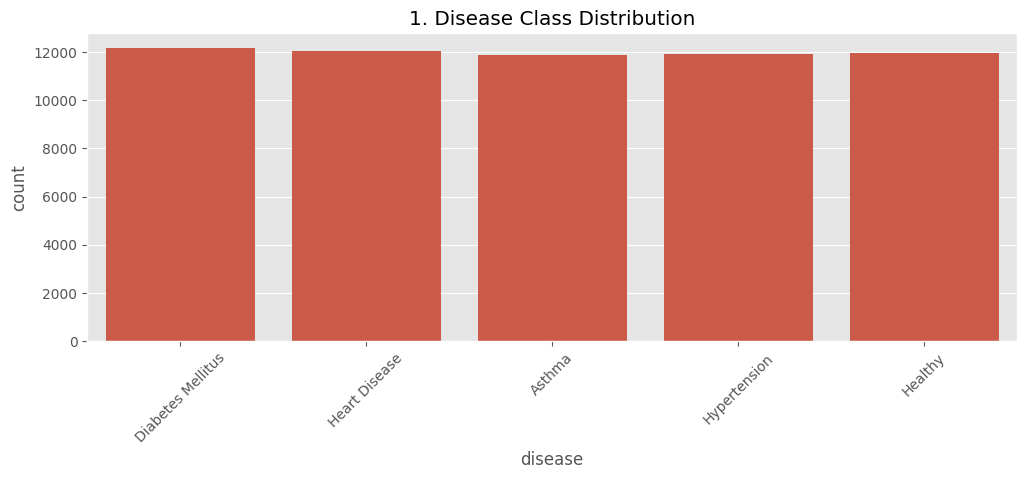

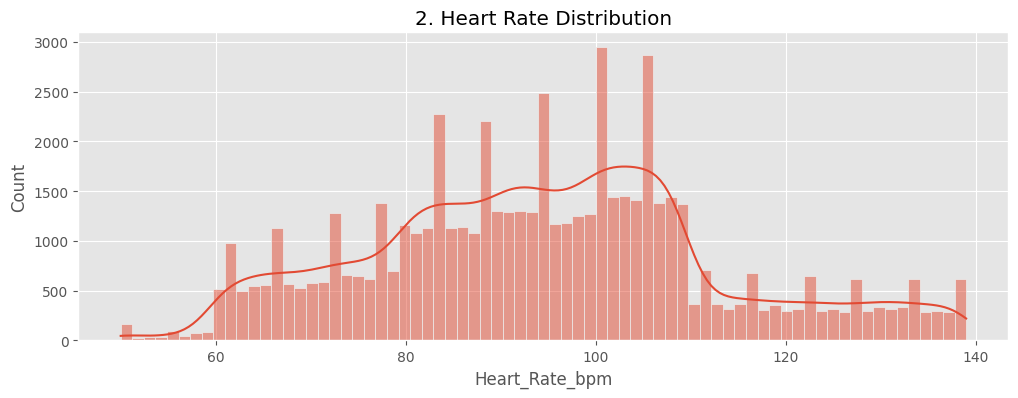

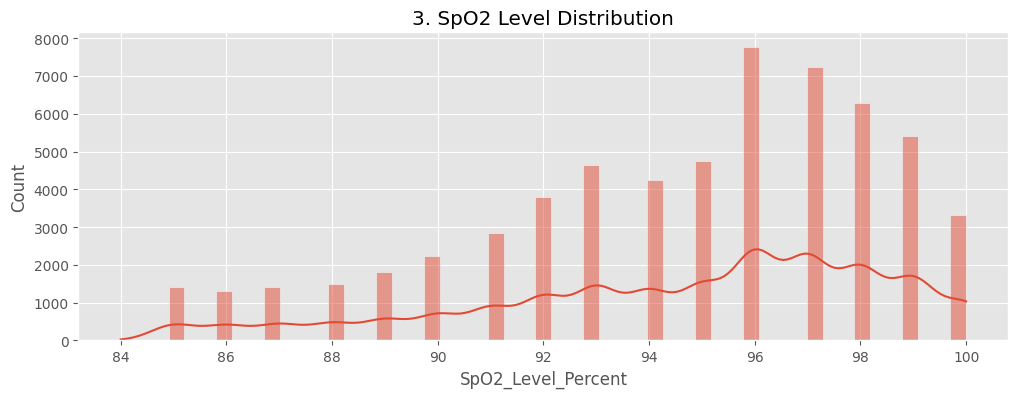

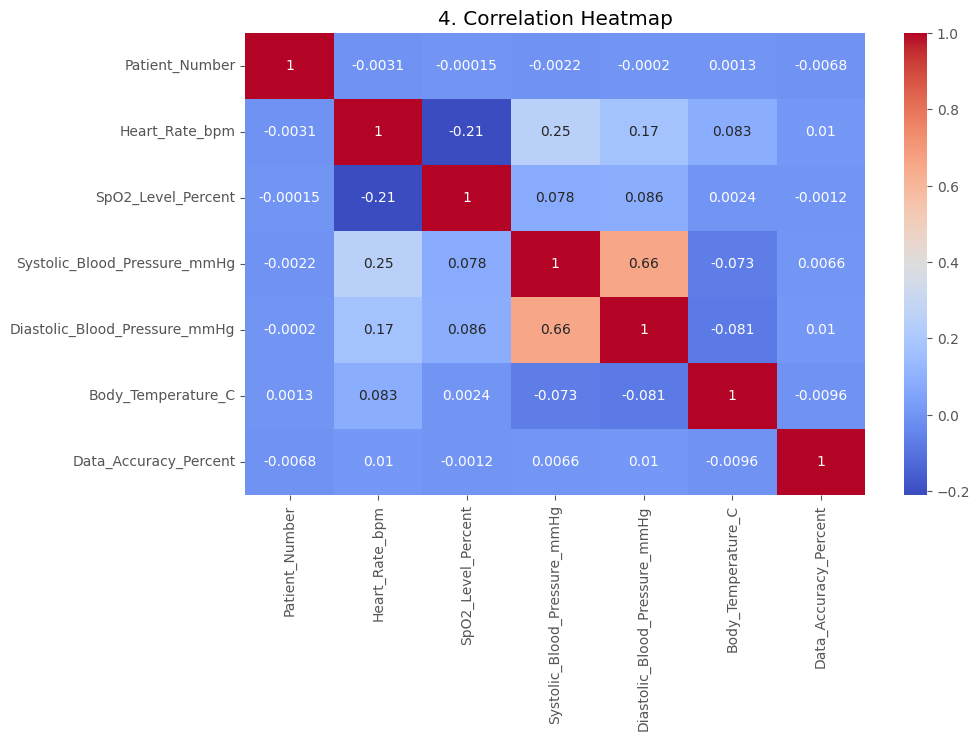

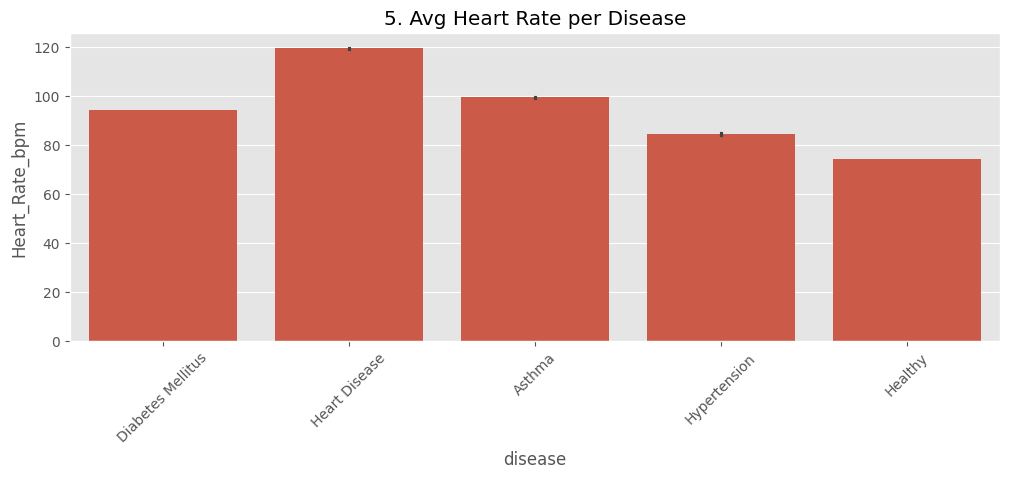

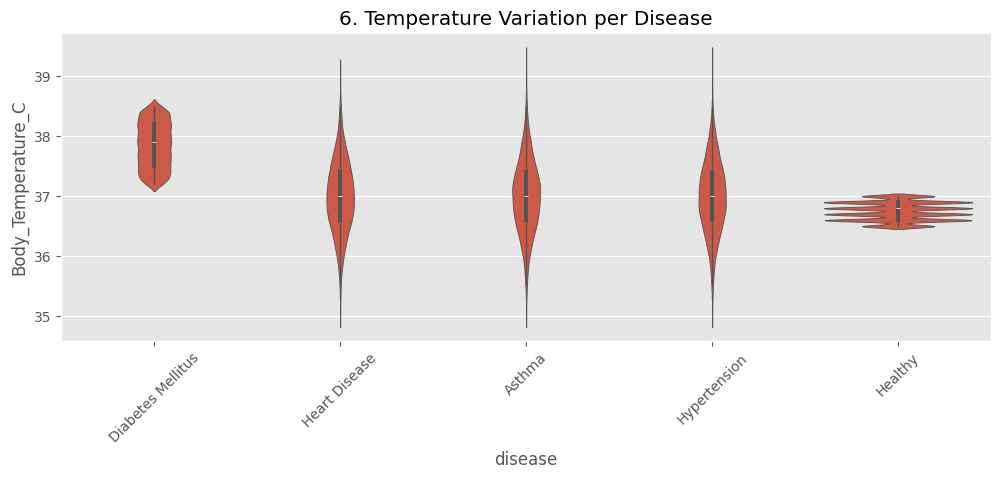

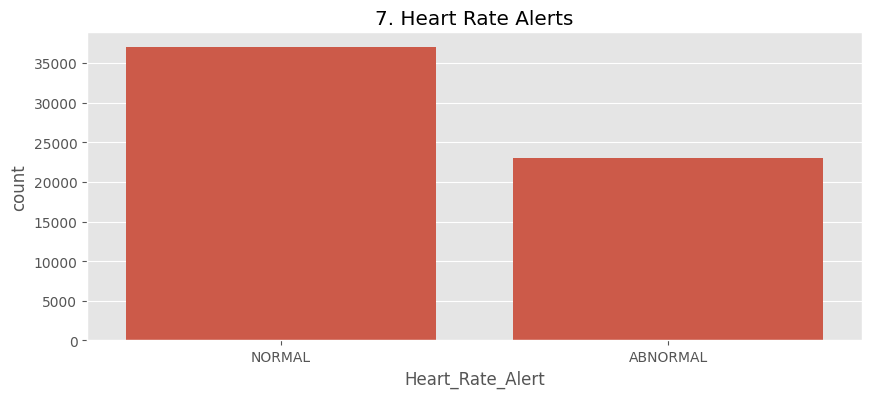

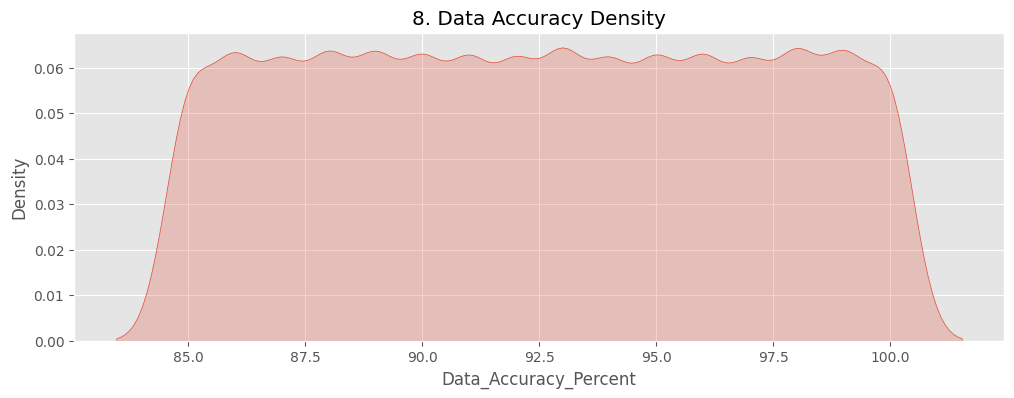

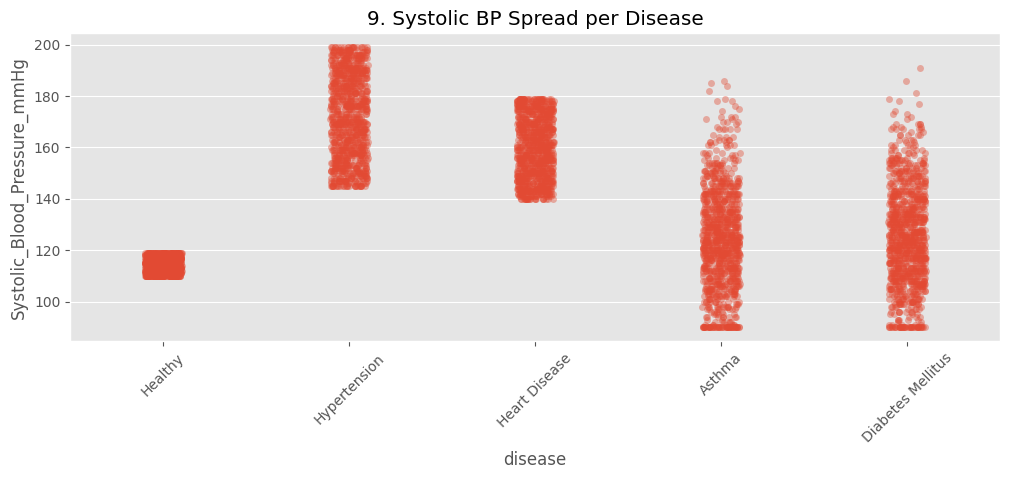

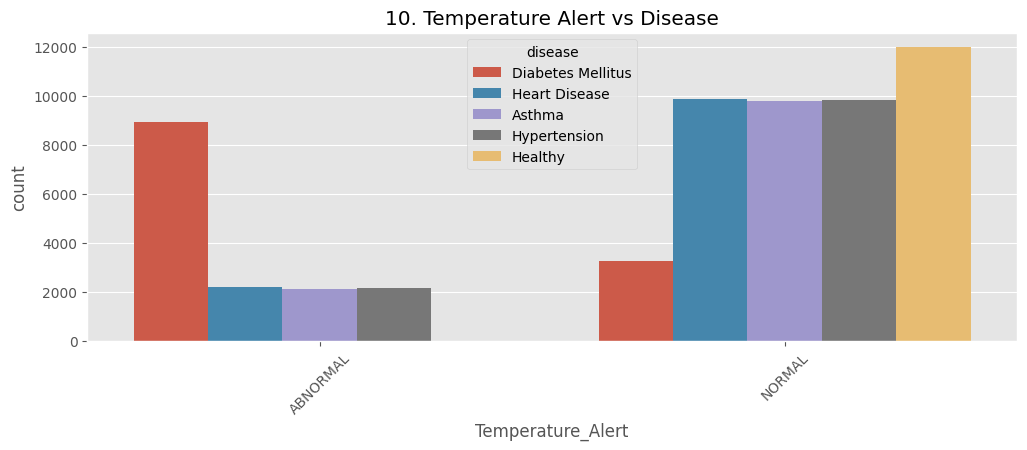


Training: Logistic Regression
Logistic Regression Accuracy: 0.8092
                   precision    recall  f1-score   support

           Asthma       0.72      0.76      0.74      2377
Diabetes Mellitus       0.69      0.57      0.62      2433
          Healthy       0.88      0.89      0.89      2395
    Heart Disease       0.84      0.90      0.87      2409
     Hypertension       0.90      0.92      0.91      2386

         accuracy                           0.81     12000
        macro avg       0.81      0.81      0.81     12000
     weighted avg       0.81      0.81      0.81     12000


Training: Random Forest
Random Forest Accuracy: 0.9513
                   precision    recall  f1-score   support

           Asthma       0.92      0.93      0.92      2377
Diabetes Mellitus       0.94      0.89      0.92      2433
          Healthy       1.00      1.00      1.00      2395
    Heart Disease       0.93      0.99      0.96      2409
     Hypertension       0.97      0.95      0.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
import joblib

# -------------------------------------------------
# Load dataset
# -------------------------------------------------
file_path = "Synthetic_patient-HealthCare-Monitoring_dataset.csv"
df = pd.read_csv(file_path)

# -------------------------------------------------
# CLEAN COLUMN NAMES SAFELY
# -------------------------------------------------
df.columns = (
    df.columns.str.strip()
              .str.replace(" ", "_")
              .str.replace("%", "Percent")
              .str.replace("(", "")
              .str.replace(")", "")
              .str.replace("°C", "C")
)

print("CLEANED COLUMNS:", df.columns.tolist())

# -------------------------------------------------
# AUTO-DETECT KEY COLUMNS (NO HARD-CODING)
# -------------------------------------------------

def find_col(keyword):
    """Finds a column containing the keyword (case-insensitive)."""
    for col in df.columns:
        if keyword.lower() in col.lower():
            return col
    return None

col_heart = find_col("Heart_Rate")
col_spo2 = find_col("SpO2")
col_temp = find_col("Temperature")
col_bp_sys = find_col("Systolic")
col_alert_hr = find_col("Heart_Rate_Alert")
col_alert_temp = find_col("Temperature_Alert")
col_accuracy = find_col("Accuracy")

print("\nAUTO-DETECTED COLUMNS:")
print("Heart Rate        →", col_heart)
print("SpO2 Level        →", col_spo2)
print("Temperature       →", col_temp)
print("Systolic BP       →", col_bp_sys)
print("Heart Alert       →", col_alert_hr)
print("Temp Alert        →", col_alert_temp)
print("Accuracy          →", col_accuracy)

# -------------------------------------------------
# Identify types
# -------------------------------------------------
target = "disease"

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != target]

cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols = [c for c in cat_cols if c != target]

# -------------------------------------------------
# ===================== 10 EDA PLOTS ==============
# -------------------------------------------------

# 1. Disease distribution
plt.figure(figsize=(12, 4))
sns.countplot(data=df, x=target)
plt.title("1. Disease Class Distribution")
plt.xticks(rotation=45)
plt.show()

# 2. Heart Rate distribution
plt.figure(figsize=(12, 4))
sns.histplot(df[col_heart], kde=True)
plt.title("2. Heart Rate Distribution")
plt.show()

# 3. SpO2 Level distribution
plt.figure(figsize=(12, 4))
sns.histplot(df[col_spo2], kde=True)
plt.title("3. SpO2 Level Distribution")
plt.show()

# 4. Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("4. Correlation Heatmap")
plt.show()

# 5. Avg Heart Rate per disease
plt.figure(figsize=(12, 4))
sns.barplot(data=df, x=target, y=col_heart)
plt.title("5. Avg Heart Rate per Disease")
plt.xticks(rotation=45)
plt.show()

# 6. Temperature violin plot
plt.figure(figsize=(12, 4))
sns.violinplot(data=df, x=target, y=col_temp)
plt.title("6. Temperature Variation per Disease")
plt.xticks(rotation=45)
plt.show()

# 7. Heart Rate Alerts
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x=col_alert_hr)
plt.title("7. Heart Rate Alerts")
plt.show()

# 8. Data Accuracy Density
plt.figure(figsize=(12, 4))
sns.kdeplot(df[col_accuracy], shade=True)
plt.title("8. Data Accuracy Density")
plt.show()

# 9. Systolic BP spread
plt.figure(figsize=(12, 4))
sns.stripplot(data=df.sample(5000), x=target, y=col_bp_sys, alpha=0.4)
plt.title("9. Systolic BP Spread per Disease")
plt.xticks(rotation=45)
plt.show()

# 10. Temperature Alerts vs Disease
plt.figure(figsize=(12, 4))
sns.countplot(data=df, x=col_alert_temp, hue=target)
plt.title("10. Temperature Alert vs Disease")
plt.xticks(rotation=45)
plt.show()

# -------------------------------------------------
# MACHINE LEARNING PIPELINE
# -------------------------------------------------

df_model = df.copy()

# Encode target
le = LabelEncoder()
df_model[target] = le.fit_transform(df_model[target])

# One-hot encode categorical columns
df_model = pd.get_dummies(df_model, columns=cat_cols)

X = df_model.drop(target, axis=1)
y = df_model[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

best_acc = 0
best_model = None

for name, model in models.items():
    print("\nTraining:", name)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)

    print(f"{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, preds, target_names=le.classes_))

    if acc > best_acc:
        best_acc = acc
        best_model = model
        best_model_name = name

joblib.dump(best_model, "best_patient_model.joblib")
print(f"\nBest Model Saved: {best_model_name} (Accuracy: {best_acc:.4f})")

# Example prediction
example = X.median().values.reshape(1, -1)
prediction = le.inverse_transform(best_model.predict(example))[0]
print("\nExample (median patient) Prediction →", prediction)
